In [19]:
# Disable JAXFEM logging
import jax_fem                       # forces setup_logger() to run NOW
import logging
jl = logging.getLogger('jax_fem')
jl.setLevel(logging.WARNING)         # or logging.ERROR to also silence INFO
jl.handlers.clear()                  # remove jax_fem's own StreamHandler
jl.propagate = False


from optimization import (
    load_eq, 
    run_filament_free, 
    increase_base_curve_order
)

from coilforce.support import CoilSupportDiscrete, CoilSupportTopBottom
from coilforce.simsopt_bridge import CoilFEMObjective

# Loading config from simsopt
from simsopt import load, save
from simsopt.configs import get_data
from simsopt.geo import plot, CurveLength
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
    RegularizedCoil, LpCurveForce,
)
from simsopt.objectives import SquaredFlux
# Import mesh and material properties
from optimization import (
    mesh_options,
    problem_options,
    material_options_const_temp,
    material_options_variable_temp,
)

import matplotlib.pyplot as plt


eq, Bnormal_plasma, plasma_surface_vc, vc = load_eq('wout.nc')
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=10, points_per_period=4)
coils_w7x = coils_via_symmetries(curves[:5], currents[:5], nfp, True)

In [20]:
coils_fixed = load('coils_fixed.json')
coils_movable = load('coils_movable.json')
coils_force = load('coils_force.json')

In [21]:
Jstress_w7x = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_w7x[:5]],
    base_currents    = [c.current for c in coils_w7x[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_force = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_force[:5]],
    base_currents    = [c.current for c in coils_force[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_fixed = load('Jstress_fixed.json')[0]
Jstress_movable = load('Jstress_movable.json')[0]

## Performing FEM calculations

In [22]:
Jstress_w7x.fem.save_run_vtu("fem_data_w7x", prefix="coil_")
Jstress_fixed.fem.save_run_vtu("fem_data_fixed", prefix="coil_")
Jstress_force.fem.save_run_vtu("fem_data_force", prefix="coil_")
result_w7x   = Jstress_w7x.run()
result_fixed = Jstress_fixed.run()
result_force = Jstress_force.run()
result_movable = Jstress_movable.run()

In [23]:
dir(Jstress_w7x.fem)

['_E',
 '_TET10_MID_EDGES',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_alpha',
 '_base_support_dofs',
 '_body_force_at_quads',
 '_compute_ref_coords',
 '_compute_support_weights',
 '_expand_geometry',
 '_final_temperature',
 '_forward_solve',
 '_fwd_preds',
 '_grid_meta',
 '_init_temperature',
 '_lam',
 '_mesh_points_from_dofs',
 '_mu',
 '_nu',
 '_problems',
 '_rho',
 '_surface_node_indices',
 '_write_coil_vtu',
 'base_currents_jax',
 'base_curves_jax',
 'base_support_fns',
 'compute_strain_tensors',
 'gravity_options',
 'mesh_opts',
 'meshes',
 'n_total',
 'nfp',
 'objective',
 'plot_support',
 'problem_options',
 'run',
 'save_run_vtu',
 'save

In [24]:
result_w7x.keys()

dict_keys(['solutions', 'displacements', 'von_mises', 'mesh_points', 'support_weights', 'f_vol', 'B_self', 'B_ext'])

## Performing force calculations

In [25]:
import numpy as np
coil_per_half_fp = 5
def calculate_forces(coils, full=False):
    if full:
        i = len(coils)
    else:
        i = coil_per_half_fp
    force_coils = [RegularizedCoil(c.curve, c.current, 0.7) for c in coils]
    Jf = LpCurveForce(
        target_coils=force_coils[:coil_per_half_fp],
        source_coils_coarse=force_coils,
    )
    forces_vec = [c.force(force_coils) for c in force_coils][:i]
    forces = [np.linalg.norm(c.force(force_coils), axis=-1) for c in force_coils][:i]
    gammas = [c.curve.gamma() for c in coils][:i]
    arclens = [np.linalg.norm(c.curve.gammadash(), axis=1) for c in coils][:i]
    lens = [CurveLength(c.curve).J() for c in coils][:i]
    return forces_vec, forces, gammas, arclens, lens, Jf

def calc_bnormal(coils, plasma_surface, Bnormal_plasma):
    bs = BiotSavart(coils)
    gamma_shape = plasma_surface.gamma().shape
    bs.set_points(plasma_surface.gamma().reshape((-1, 3)))
    B_normal = np.sum(bs.B().reshape(gamma_shape) * plasma_surface.unitnormal(), axis=-1)
    Jf_norm = SquaredFlux(
        plasma_surface,
        bs,
        target=Bnormal_plasma,
        definition='normalized',
    )
    return B_normal, bs, Jf_norm

def pct_change(before, after):
    return round((after - before)/before*100, 1)

In [26]:
(
    forces_vec_fixed, 
    forces_fixed, 
    gamma_fixed, 
    arclens_fixed, 
    lens_fixed, 
    Jf_fixed
) = calculate_forces(coils_fixed)
(
    forces_vec_movable, 
    forces_movable, 
    gamma_movable, 
    arclens_movable, 
    lens_movable, 
    Jf_movable
) = calculate_forces(coils_movable)
(
    forces_vec_force, 
    forces_force, 
    gamma_force, 
    arclens_force, 
    lens_force, 
    Jf_force
) = calculate_forces(coils_force)
(
    forces_vec_w7x, 
    forces_w7x, 
    gamma_w7x, 
    arclens_w7x, 
    lens_w7x, 
    Jf_w7x
) = calculate_forces(coils_w7x)
(B_normal_fixed  , bs_fixed  , Jf_norm_fixed  ) = calc_bnormal(coils_fixed,   plasma_surface_vc, Bnormal_plasma)
(B_normal_movable, bs_movable, Jf_norm_movable) = calc_bnormal(coils_movable, plasma_surface_vc, Bnormal_plasma)
(B_normal_force  , bs_force  , Jf_norm_force  ) = calc_bnormal(coils_force,   plasma_surface_vc, Bnormal_plasma)
(B_normal_w7x    , bs_w7x    , Jf_norm_w7x    ) = calc_bnormal(coils_w7x,     plasma_surface_vc, Bnormal_plasma)
maxabs = lambda x: np.max(np.abs(x))
RMS = lambda x, arclens: np.sqrt(np.sum(np.array(x)**2 * arclens) / np.sum(arclens))
max_force_fixed   = maxabs(forces_fixed)
max_force_movable = maxabs(forces_movable)
max_force_force   = maxabs(forces_force)
max_force_w7x     = maxabs(forces_w7x)
RMS_force_fixed   = RMS(forces_fixed, arclens_fixed)
RMS_force_movable = RMS(forces_movable, arclens_movable)
RMS_force_force   = RMS(forces_force, arclens_force)
RMS_force_w7x     = RMS(forces_w7x, arclens_w7x)
Jstress_val_fixed   = Jstress_fixed.J()
Jstress_val_movable = Jstress_movable.J()
Jstress_val_force   = Jstress_force.J()
Jstress_val_w7x     = Jstress_w7x.J()
Jf_norm_val_fixed   = Jf_norm_fixed.J()
Jf_norm_val_movable = Jf_norm_movable.J()
Jf_norm_val_force   = Jf_norm_force.J()
Jf_norm_val_w7x     = Jf_norm_w7x.J()
print('L2 von mises     w7x', Jstress_val_w7x)
print('L2 von mises   fixed', Jstress_val_fixed,   'change (%)', pct_change(Jstress_val_w7x, Jstress_val_fixed))
print('L2 von mises movable', Jstress_val_movable, 'change (%)', pct_change(Jstress_val_w7x, Jstress_val_movable))
print('L2 von mises   force', Jstress_val_force,   'change (%)', pct_change(Jstress_val_w7x, Jstress_val_force))
print('Forces     w7x - max:', max_force_w7x)
print('Forces   fixed - max:', max_force_fixed,   'change (%)', pct_change(max_force_w7x, max_force_fixed))
print('Forces movable - max:', max_force_movable, 'change (%)', pct_change(max_force_w7x, max_force_movable))
print('Forces   force - max:', max_force_force,   'change (%)', pct_change(max_force_w7x, max_force_force))
print('Forces     w7x - RMS:', RMS_force_w7x)
print('Forces   fixed - RMS:', RMS_force_fixed,   'change (%)', pct_change(RMS_force_w7x, RMS_force_fixed))
print('Forces movable - RMS:', RMS_force_movable, 'change (%)', pct_change(RMS_force_w7x, RMS_force_movable))
print('Forces   force - RMS:', RMS_force_force,   'change (%)', pct_change(RMS_force_w7x, RMS_force_force))
print('Normalized squared flux     w7x:', Jf_norm_val_w7x)
print('Normalized squared flux   fixed:', Jf_norm_val_fixed, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_fixed))
print('Normalized squared flux movable:', Jf_norm_val_movable, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_movable))
print('Normalized squared flux   force:', Jf_norm_val_force, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_force))

L2 von mises     w7x 2.058220556679802e+17
L2 von mises   fixed 1.9052819831901334e+17 change (%) -7.4
L2 von mises movable 2.213667177489537e+16 change (%) -89.2
L2 von mises   force 1.6744240938233e+17 change (%) -18.6
Forces     w7x - max: 3532974.063967581
Forces   fixed - max: 3659377.4212987493 change (%) 3.6
Forces movable - max: 3424449.2496898635 change (%) -3.1
Forces   force - max: 3379273.345083474 change (%) -4.4
Forces     w7x - RMS: 1898558.1117223531
Forces   fixed - RMS: 1891649.612640977 change (%) -0.4
Forces movable - RMS: 1878285.588482016 change (%) -1.1
Forces   force - RMS: 1852366.890131735 change (%) -2.4
Normalized squared flux     w7x: 5.435032925907492e-07
Normalized squared flux   fixed: 5.828794904247409e-06 change (%) 972.4
Normalized squared flux movable: 7.999520952687707e-06 change (%) 1371.8
Normalized squared flux   force: 1.6146943853129535e-06 change (%) 197.1


(<Figure size 640x480 with 2 Axes>,
 <Axes3D: xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>)

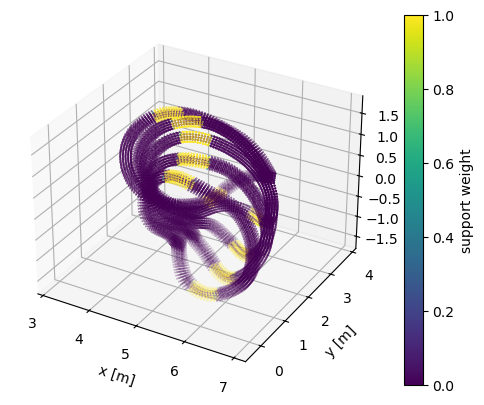

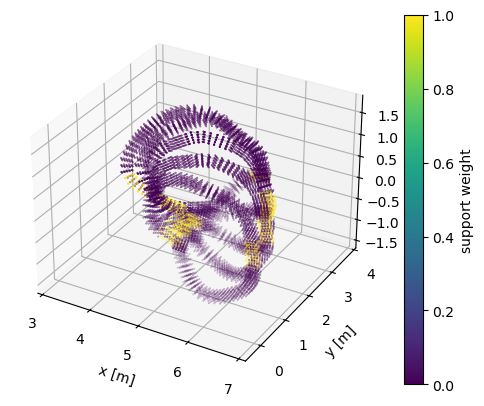

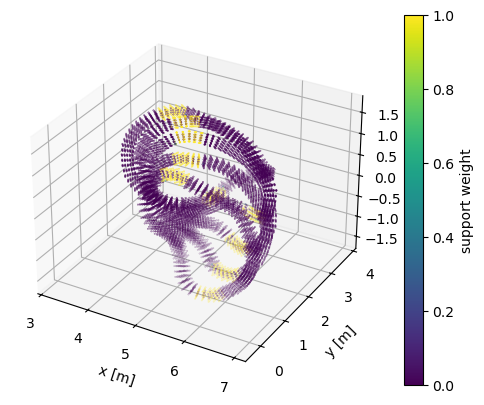

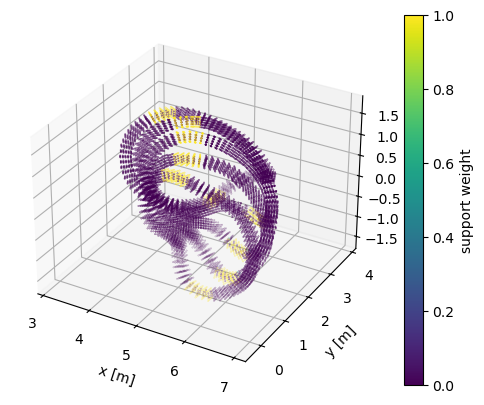

In [28]:
Jstress_fixed.plot_support()
Jstress_movable.plot_support()
Jstress_force.plot_support()
Jstress_w7x.plot_support()

In [30]:
def calc_obj(name, base_curves, base_currents):
    Jstress = CoilFEMObjective(
        base_curves      = base_curves,
        base_currents    = base_currents,
        base_supports    = [support_type(**support_kwargs)
                            for _ in base_curves],
        metrics          = (name,),
        metric_weights   = (1.,),
        nfp              = plasma_surface.nfp,
        stellsym         = plasma_surface.stellsym,
        mesh_options     = mesh_options,
        material_options = material_options_const_temp,
        problem_options  = problem_options,
    )
    return Jstress.J()

In [31]:
result_force.keys()

dict_keys(['solutions', 'displacements', 'von_mises', 'mesh_points', 'support_weights', 'f_vol', 'B_self', 'B_ext'])

In [32]:
result_w7x['von_mises'][0].shape

(960, 4)

In [33]:
displacements_w7x = [np.linalg.norm(d, axis=-1) for d in result_w7x['displacements']]
displacements_fixed = [np.linalg.norm(d, axis=-1) for d in result_fixed['displacements']]
displacements_force = [np.linalg.norm(d, axis=-1) for d in result_force['displacements']]
displacements_everything = np.array([
    displacements_w7x,
    displacements_fixed,
    displacements_force,
])
vm_w7x = result_w7x['von_mises']
vm_fixed = result_fixed['von_mises']
vm_force = result_force['von_mises']
vm_everything = np.array([
    vm_w7x,
    vm_fixed,
    vm_force,
])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (3, 5) + inhomogeneous part.

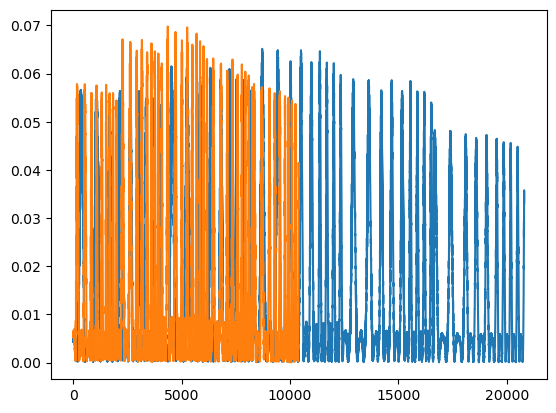

In [34]:
plt.plot(np.array(displacements_fixed).flatten())
plt.plot(np.array(displacements_w7x).flatten())

In [35]:
print(np.max(vm_w7x))
print(np.max(vm_fixed))
print(np.max(vm_force))

NameError: name 'vm_w7x' is not defined

In [36]:
Jstress_w7x.J()

2.058220556679802e+17

In [37]:
plt.figure(figsize=(8, 4))

bins = np.linspace(
    np.min(displacements_everything),
    np.max(displacements_everything),
    20
)
plt.hist(
    np.array(displacements_w7x).flatten(),
    bins=bins,
    # fill=False,
    label='W7X',
    # histtype='step',
    color='orange'
)
plt.hist(
    np.array(displacements_force).flatten(),
    bins=bins,
    fill=False,
    label='Force optimization',
    histtype='step',
    color='tab:green',
    linestyle='dashed',
    linewidth=1.5
)
plt.hist(
    np.array(displacements_fixed).flatten(),
    bins=bins,
    fill=False,
    label='Fixed support',
    histtype='step',
    color='tab:blue',
    linewidth=1.5
)
plt.ylabel('Mesh point count')
plt.xlabel('Displacements (m)')
plt.legend()
# plt.savefig('../plots_final/hist_force.pdf', bbox_inches='tight')

NameError: name 'displacements_everything' is not defined

<Figure size 800x400 with 0 Axes>

In [38]:
plt.figure(figsize=(8, 4))

bins = np.linspace(
    np.min(vm_everything),
    np.max(vm_everything),
    20
)
plt.hist(
    np.array(vm_w7x).flatten(),
    bins=bins,
    # fill=False,
    label='W7X',
    # histtype='step',
    color='orange'
)
plt.hist(
    np.array(vm_force).flatten(),
    bins=bins,
    fill=False,
    label='Force optimization',
    histtype='step',
    color='tab:green',
    linestyle='dashed',
    linewidth=1.5
)
plt.hist(
    np.array(vm_fixed).flatten(),
    bins=bins,
    fill=False,
    label='Fixed support',
    histtype='step',
    color='tab:blue',
    linewidth=1.5
)
plt.ylabel('Mesh point count')
plt.xlabel('Von mises stress (Pa)')
plt.legend()
# plt.savefig('../plots_final/hist_force.pdf', bbox_inches='tight')

NameError: name 'vm_everything' is not defined

<Figure size 800x400 with 0 Axes>

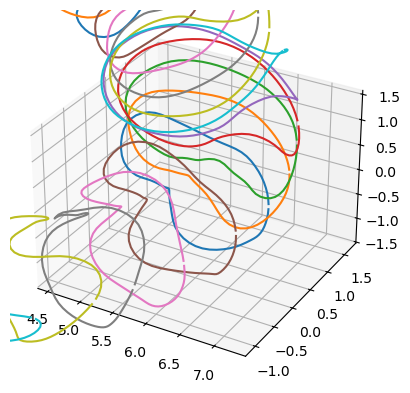

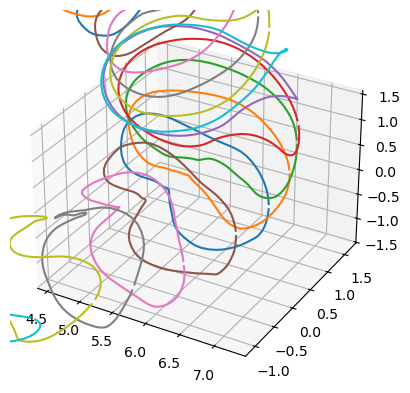

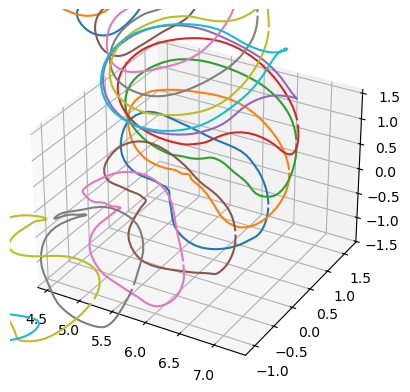

<Axes3D: >

In [27]:
plot(coils_w7x)
plot(coils_fixed)
plot(coils_force)